<a href="https://colab.research.google.com/github/kundankumar09-v/weekly_assignments_CEI/blob/main/week2_kundan_kumar_vennaboina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

## Data Loading

In [2]:
df=pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")

## Data Understanding

In [3]:
df

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


## Data Preprocessing

In [5]:
df.shape


(2640, 12)

In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [7]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [8]:
print(df.duplicated().sum())

0


In [9]:
df = df.drop_duplicates()

In [10]:
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' +df['Month'].astype(str) + '-01')
df = df.sort_values('Date')

## Exploratory Data Analysis (EDA)

<Axes: xlabel='Date'>

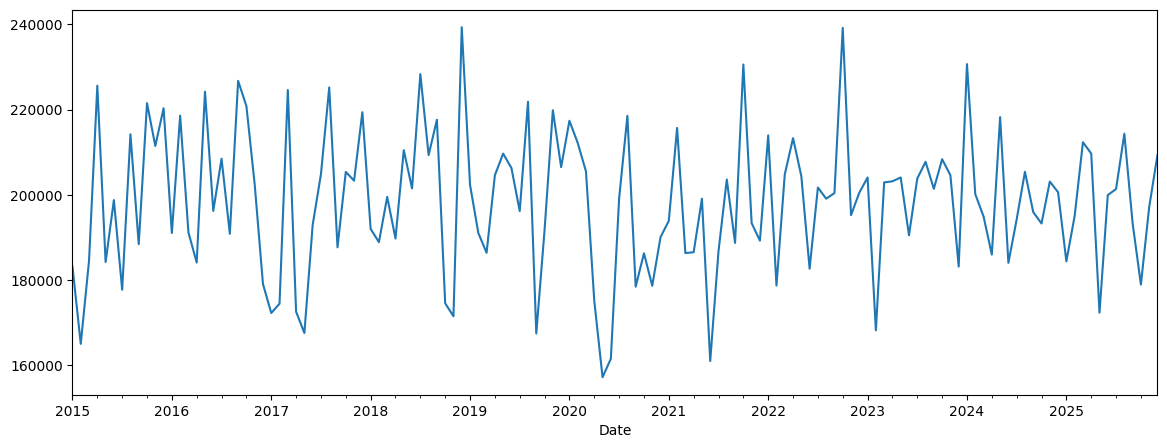

In [11]:
monthly_sales = df.groupby('Date')['Estimated_Deliveries'].sum()
monthly_sales.plot(figsize=(14,5))

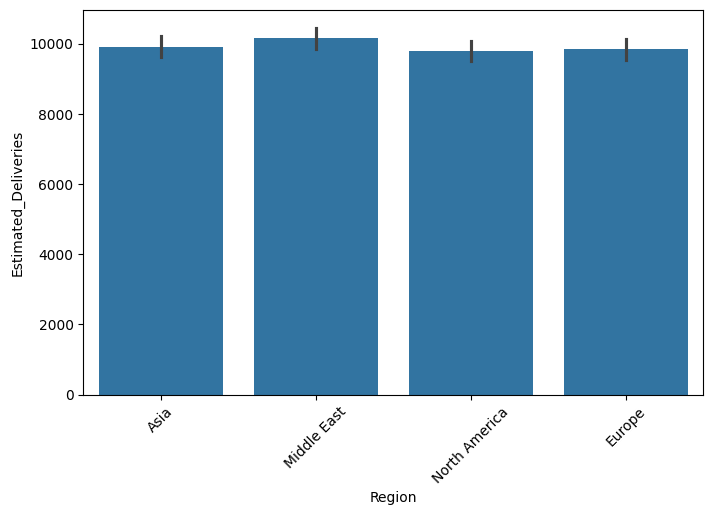

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='Region',y='Estimated_Deliveries',estimator='mean')
plt.xticks(rotation=45)
plt.show()

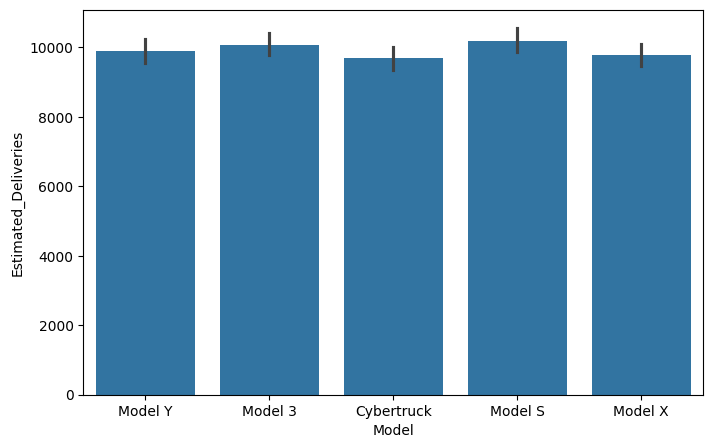

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x='Model',y='Estimated_Deliveries',estimator='mean')
plt.show()

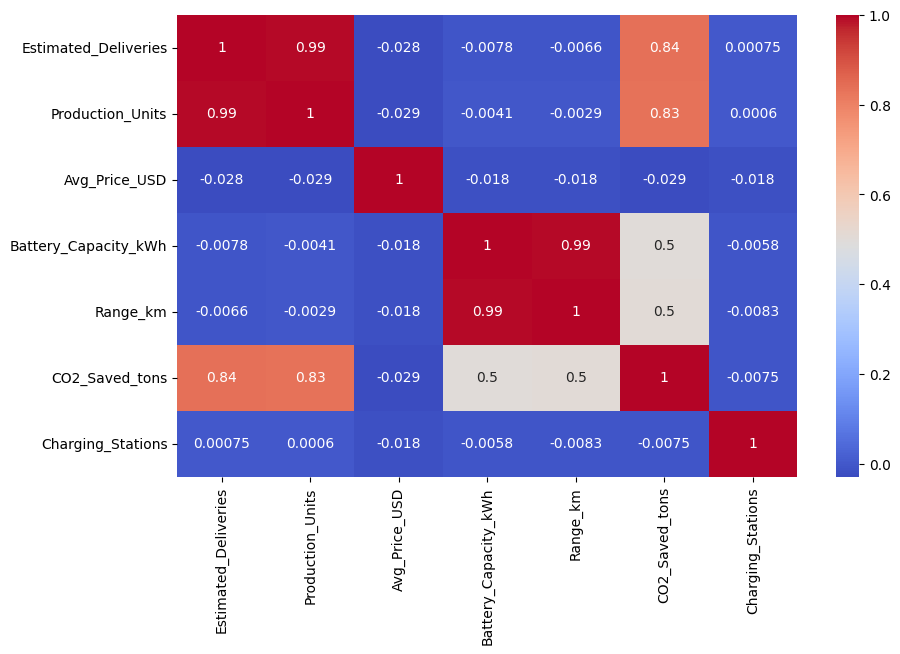

In [14]:
num_cols = ['Estimated_Deliveries','Production_Units','Avg_Price_USD','Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm')
plt.show()

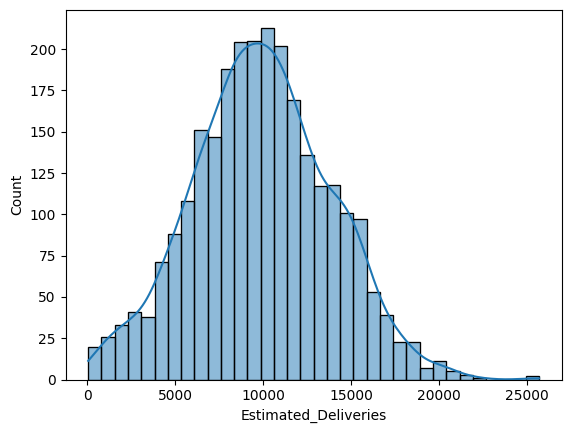

In [15]:
sns.histplot(df['Estimated_Deliveries'], kde=True)
plt.show()

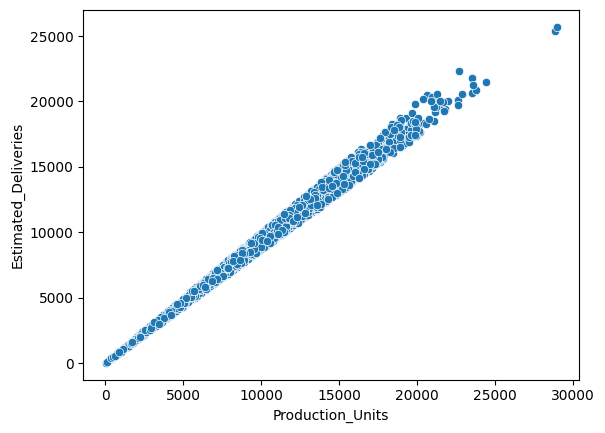

In [16]:
sns.scatterplot(data=df,x='Production_Units',y='Estimated_Deliveries')
plt.show()

### Outlier Detection (Boxplots)

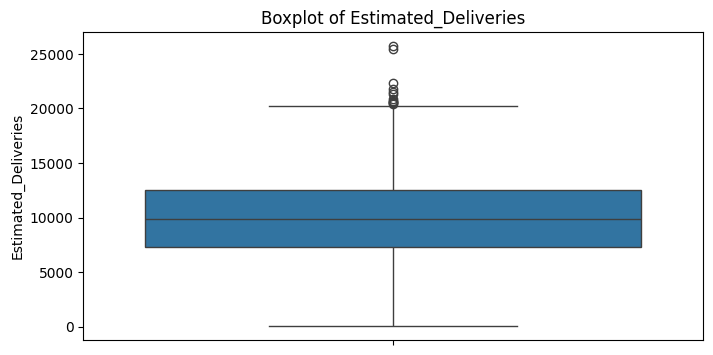

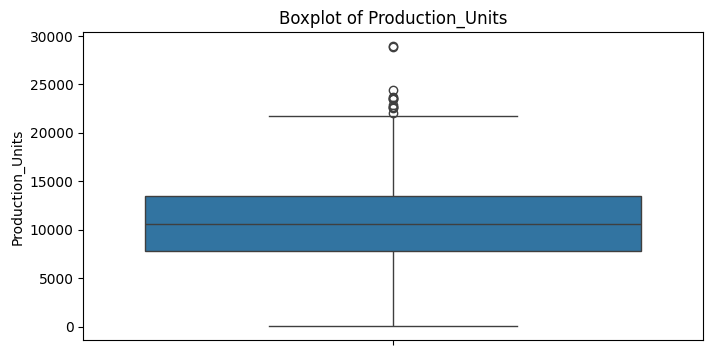

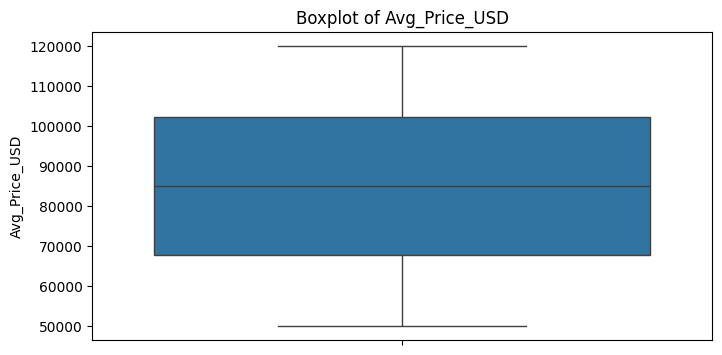

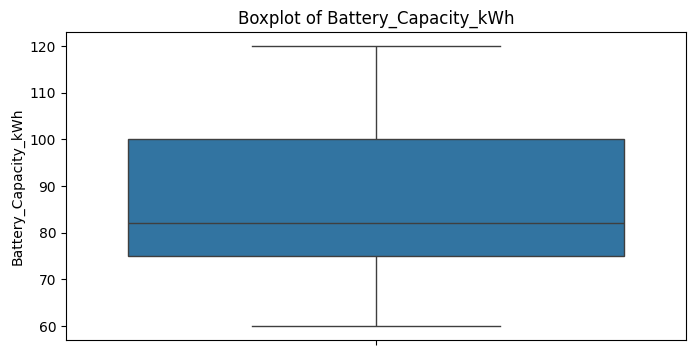

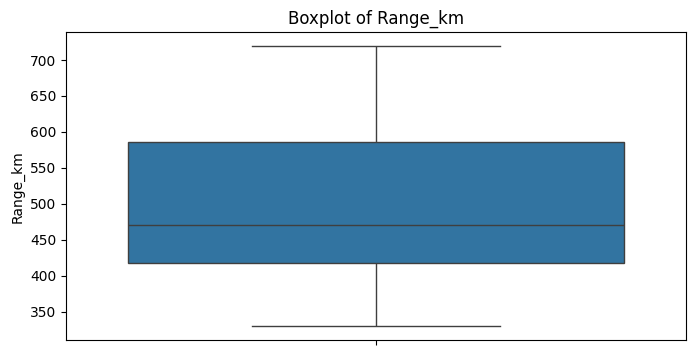

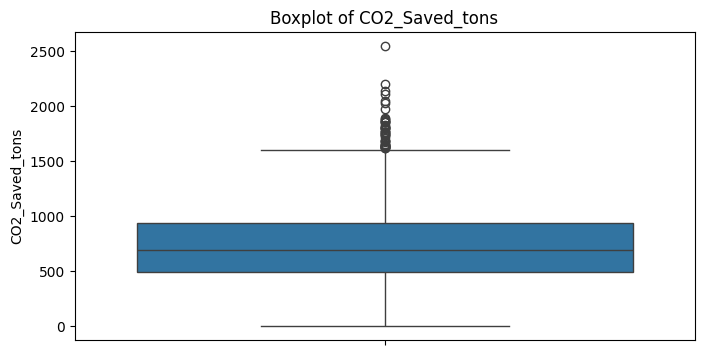

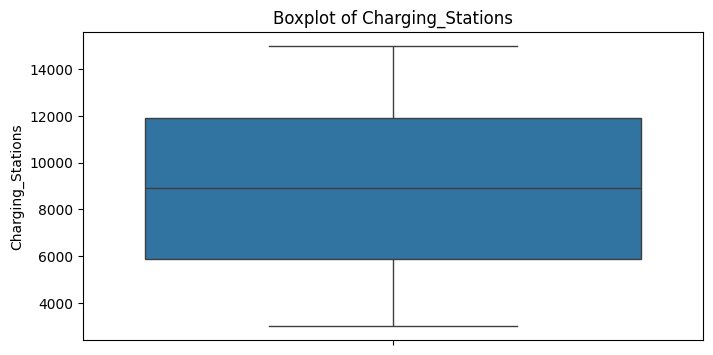

In [17]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

## Feature Engineering

In [18]:
df['Quarter'] = ((df['Month'] - 1)//3) + 1
df['Month_Sin'] = np.sin(2*np.pi*df['Month']/12)
df['Month_Cos'] = np.cos(2*np.pi*df['Month']/12)

## Data Preparation

In [19]:
y = df['Estimated_Deliveries']
X = df.drop(columns=['Estimated_Deliveries','Date'])

In [20]:
X = pd.get_dummies(X,columns=['Region','Model','Source_Type'],drop_first=True)

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Regression Modeling

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
lr = LinearRegression()
lr.fit(X_train,y_train)
pred_lr = lr.predict(X_test)
print("R2:",r2_score(y_test,pred_lr))
print("MAE:",mean_absolute_error(y_test,pred_lr))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_lr)))

R2: 0.9902567818646351
MAE: 312.2765476719008
RMSE: 382.07359813218807


In [24]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("R2:", r2_score(y_test, pred_rf))
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))

R2: 0.9897348839884729
MAE: 302.33651515151513
RMSE: 392.1730505204883


In [25]:
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42,n_estimators=200,max_depth=5,learning_rate=0.1)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
print("R2:", r2_score(y_test, pred_xgb))
print("MAE:", mean_absolute_error(y_test, pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_xgb)))

R2: 0.9935801029205322
MAE: 235.6595001220703
RMSE: 310.1416133196253


## Hyperparameter Tuning

In [26]:
from sklearn.model_selection import RandomizedSearchCV
params = {'n_estimators':[100,200,300,500],'max_depth':[3,5,7,9],'learning_rate':[0.01,0.05,0.1,0.2],'subsample':[0.8,0.9,1.0],'colsample_bytree':[0.8,0.9,1.0]}
search = RandomizedSearchCV(XGBRegressor(random_state=42),param_distributions=params,n_iter=20,cv=5,scoring='r2',random_state=42,n_jobs=-1)
search.fit(X_train, y_train)
print(search.best_params_)
print(search.best_score_)

{'subsample': 0.9, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
0.9936910271644592


In [27]:
best_xgb = XGBRegressor(random_state=42,n_estimators=500,max_depth=3,learning_rate=0.2,subsample=0.9,colsample_bytree=0.9)
best_xgb.fit(X_train, y_train)
pred_best = best_xgb.predict(X_test)
print("R2:", r2_score(y_test, pred_best))
print("MAE:", mean_absolute_error(y_test, pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_best)))

R2: 0.9963194131851196
MAE: 182.62387084960938
RMSE: 234.82982535231764


## Model Evaluation and Comparison

### Model Comparison

In [28]:
model_names = ['Linear Regression', 'Random Forest', 'XGBoost (Untuned)', 'XGBoost (Tuned)']
r2_scores = [r2_score(y_test, pred_lr), r2_score(y_test, pred_rf), r2_score(y_test, pred_xgb), r2_score(y_test, pred_best)]
mae_scores = [mean_absolute_error(y_test, pred_lr), mean_absolute_error(y_test, pred_rf), mean_absolute_error(y_test, pred_xgb), mean_absolute_error(y_test, pred_best)]
rmse_scores = [np.sqrt(mean_squared_error(y_test, pred_lr)), np.sqrt(mean_squared_error(y_test, pred_rf)), np.sqrt(mean_squared_error(y_test, pred_xgb)), np.sqrt(mean_squared_error(y_test, pred_best))]

comparison_df = pd.DataFrame({
    'Model': model_names,
    'R2 Score': r2_scores,
    'MAE': mae_scores,
    'RMSE': rmse_scores
})

display(comparison_df.sort_values(by='R2 Score', ascending=False))

,Model,R2 Score,MAE,RMSE
3,XGBoost (Tuned),0.996319,182.623871,234.829825
2,XGBoost (Untuned),0.993580,235.659500,310.141613
0,Linear Regression,0.990257,312.276548,382.073598
1,Random Forest,0.989735,302.336515,392.173051


### Actual vs Predicted Scatter Plot (Tuned XGBoost)

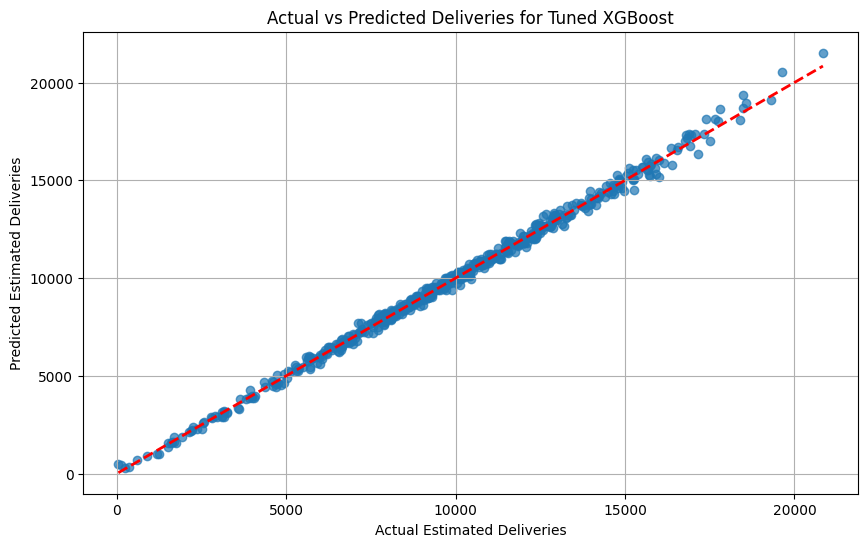

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred_best, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Estimated Deliveries')
plt.ylabel('Predicted Estimated Deliveries')
plt.title('Actual vs Predicted Deliveries for Tuned XGBoost')
plt.grid(True)
plt.show()

## Feature Importance Analysis

In [30]:
importance = pd.Series(best_xgb.feature_importances_,index=X.columns).sort_values(ascending=False)
print(importance.head(10))

Production_Units        0.764189
CO2_Saved_tons          0.153805
Range_km                0.039995
Model_Model 3           0.007855
Region_Middle East      0.006189
Battery_Capacity_kWh    0.003831
Month                   0.002875
Year                    0.002647
Avg_Price_USD           0.002372
Region_Europe           0.002022
dtype: float32


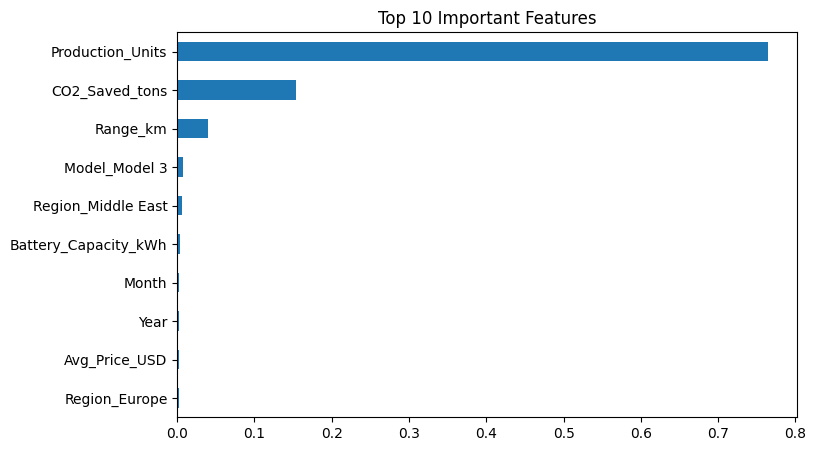

In [31]:
importance.head(10).sort_values().plot(kind='barh',figsize=(8,5))
plt.title("Top 10 Important Features")
plt.show()

In [32]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print(f'ADF Statistic: {result[0]:.2f}')
    print(f'p-value: {result[1]:.2f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'    {key}: {value:.2f}')
    if result[1] <= 0.05:
        print('Reject the null hypothesis (H0), the series is stationary.')
    else:
        print('Fail to reject the null hypothesis (H0), the series is non-stationary.')

monthly = df.groupby('Date')['Estimated_Deliveries'].sum()
print('ADF Test for Monthly Estimated Deliveries:')
adf_test(monthly)

ADF Test for Monthly Estimated Deliveries:
ADF Statistic: -8.88
p-value: 0.00
Critical Values:
    1%: -3.48
    5%: -2.88
    10%: -2.58
Reject the null hypothesis (H0), the series is stationary.


In [33]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
monthly = df.groupby('Date')['Estimated_Deliveries'].sum()
model = ExponentialSmoothing(monthly,trend='add',seasonal='add',seasonal_periods=12)
fit = model.fit()
forecast = fit.forecast(12)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [34]:
print(forecast)

2026-01-01    192503.413088
2026-02-01    190435.129208
2026-03-01    198070.502476
2026-04-01    189794.124276
2026-05-01    197737.023790
2026-06-01    192220.156886
2026-07-01    201206.012233
2026-08-01    208206.054814
2026-09-01    198374.685638
2026-10-01    203016.972600
2026-11-01    195870.464575
2026-12-01    206739.087753
Freq: MS, dtype: float64


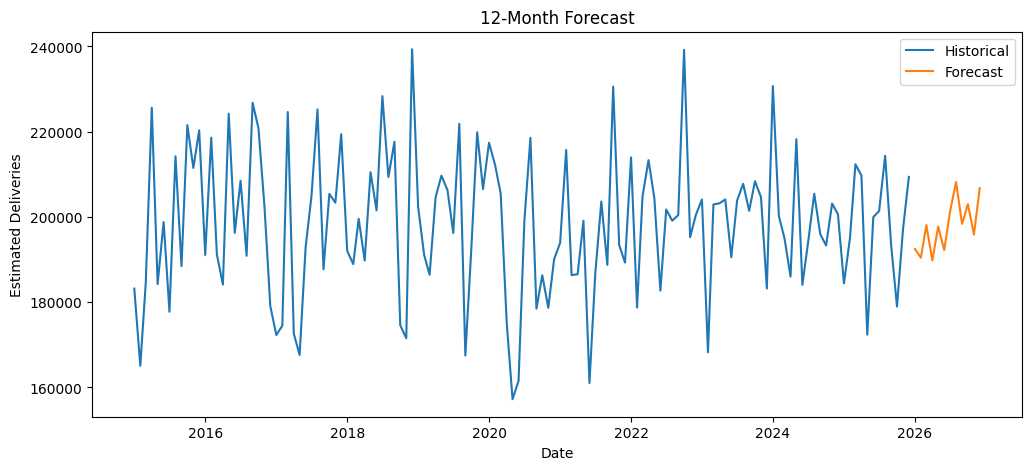

In [35]:
plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly.values, label='Historical')
plt.plot(forecast.index, forecast.values, label='Forecast')
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.title("12-Month Forecast")
plt.legend()
plt.show()

In [36]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(monthly, order=(1,1,1))
fit = model.fit()
forecast_arima = fit.forecast(steps=12)
print(forecast_arima)

2026-01-01    201130.711312
2026-02-01    199815.368230
2026-03-01    199605.917024
2026-04-01    199572.564655
2026-05-01    199567.253726
2026-06-01    199566.408030
2026-07-01    199566.273364
2026-08-01    199566.251920
2026-09-01    199566.248506
2026-10-01    199566.247962
2026-11-01    199566.247875
2026-12-01    199566.247862
Freq: MS, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


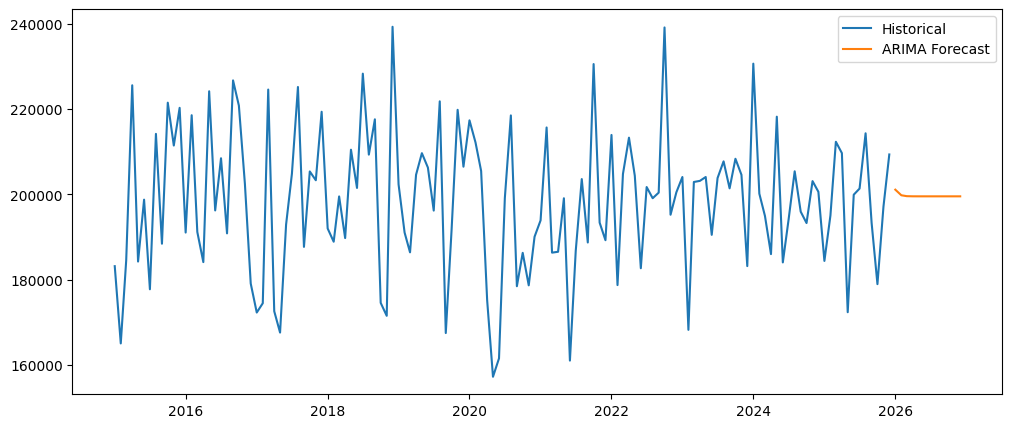

In [37]:
plt.figure(figsize=(12,5))
plt.plot(monthly, label='Historical')
plt.plot(forecast_arima.index,forecast_arima.values,label='ARIMA Forecast')
plt.legend()
plt.show()

### Forecast Comparison and Interpretation

Comparing the Holt-Winters Exponential Smoothing and ARIMA forecasts, Holt-Winters appears to provide a more nuanced prediction, capturing potential seasonal fluctuations more effectively. The ARIMA forecast, while providing initial predictions, quickly flattens out, suggesting it may not be fully capturing the underlying time-series patterns. Holt-Winters, with its additive trend and seasonal components, offers a prediction that better reflects the historical monthly variations, indicating stable demand throughout 2026 with an oscillatory pattern.